# Perturbation Method Visualization

Visualize the four perturbation methods used in Phase 3 / 4:

- **Per-spike jitter** (`jitter_train.ipynb`): each spike shifted by an independent Gaussian offset.
- **Per-neuron shift** (`shift_train.ipynb`): all spikes from a given neuron shifted by the same Gaussian offset (preserves intra-neuron ISI).
- **Per-spike deletion** (`deletion_train.ipynb`): each spike independently removed with probability `p_d`.
- **Time reversal / inverse** (`inverse_train.ipynb`): the sample's spike trains are flipped within the sample-wide active window (earliest to latest spike across all neurons). Preserves spike counts, per-neuron ISI, and cross-neuron coincidences; only the direction of time is reversed.

A synthetic **fixed-interval** spike train is used as the example input: each neuron fires at a constant ISI, with a random initial phase so neurons are not all synchronised. Original spikes are shown in black, perturbed spikes in red.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

RNG_SEED = 0
NUM_NEURONS = 224
TIME_STEPS = 100
FIRING_RATE = 0.05  # mean spikes per time step → base ISI = round(1 / rate)

# Set to True  → every neuron uses the same ISI (only phase differs).
# Set to False → each neuron draws its own ISI uniformly from
#                [ISI_MIN, ISI_MAX], giving a spread of firing rates.
UNIFORM_RATE: bool = True
ISI_MIN: int = 10   # shortest ISI when UNIFORM_RATE is False
ISI_MAX: int = 30   # longest  ISI when UNIFORM_RATE is False

# Set to True  → all neurons share phase 0 (spikes perfectly synchronised).
# Set to False → each neuron draws an independent random phase in [0, ISI).
UNIFORM_PHASE: bool = True


def make_fixed_interval_spike_train(
    num_neurons: int,
    time_steps: int,
    rate: float,
    uniform_rate: bool = True,
    isi_min: int = 10,
    isi_max: int = 30,
    uniform_phase: bool = False,
    seed: int = 0,
) -> np.ndarray:
    """Generate a binary spike train with fixed inter-spike intervals.

    Each neuron fires periodically at a constant ISI. When
    ``uniform_rate=True`` all neurons share the same ISI
    (= ``round(1 / rate)``); otherwise each neuron draws its own ISI
    from ``[isi_min, isi_max]``. When ``uniform_phase=True`` all neurons
    start at phase 0 (fully synchronised); otherwise each neuron gets an
    independent random phase in ``[0, ISI)``.

    Args:
        num_neurons: Number of neurons (rows).
        time_steps: Number of time bins (columns).
        rate: Mean spikes per time step; sets the shared ISI when
            ``uniform_rate=True``.
        uniform_rate: If True, all neurons fire at the same rate.
        isi_min: Minimum ISI (inclusive) when ``uniform_rate=False``.
        isi_max: Maximum ISI (inclusive) when ``uniform_rate=False``.
        uniform_phase: If True, all neurons fire at phase 0.
        seed: Random seed for reproducibility.

    Returns:
        Binary array of shape ``(num_neurons, time_steps)``.
    """
    rng = np.random.default_rng(seed)
    base_isi = max(1, round(1.0 / rate))
    spike_train = np.zeros((num_neurons, time_steps), dtype=np.int8)

    for neuron_idx in range(num_neurons):
        isi = base_isi if uniform_rate else int(rng.integers(isi_min, isi_max + 1))
        phase = 0 if uniform_phase else int(rng.integers(0, isi))
        spike_times = np.arange(phase, time_steps, isi)
        spike_train[neuron_idx, spike_times] = 1

    return spike_train


original_spikes = make_fixed_interval_spike_train(
    NUM_NEURONS, TIME_STEPS, FIRING_RATE,
    uniform_rate=UNIFORM_RATE,
    isi_min=ISI_MIN,
    isi_max=ISI_MAX,
    uniform_phase=UNIFORM_PHASE,
    seed=RNG_SEED,
)
print(f"Spike train shape: {original_spikes.shape}")
print(f"Uniform rate:  {UNIFORM_RATE}", end="")
if UNIFORM_RATE:
    print(f"  (ISI = {max(1, round(1.0 / FIRING_RATE))} for all neurons)")
else:
    print(f"  (ISI ∈ [{ISI_MIN}, {ISI_MAX}] per neuron)")
print(f"Uniform phase: {UNIFORM_PHASE}")
print(f"Total spikes:  {int(original_spikes.sum())}")

Spike train shape: (224, 100)
Uniform rate:  True  (ISI = 20 for all neurons)
Uniform phase: True
Total spikes:  1120


## Perturbation functions

Copied from the three training notebooks so the visualization reflects exactly the perturbations applied during training.

In [22]:
def jitter_spike_train(
    spike_train: np.ndarray,
    sigma: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Apply per-spike Gaussian jitter to a binary spike train.

    Each spike is shifted by an independent offset drawn from ``N(0, sigma)``.
    The new time is clipped to ``[0, T-1]``. If the target bin is already
    occupied, retry up to ``max_attempts`` times; on failure, keep the
    spike at its original time.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.
        sigma: Standard deviation of the Gaussian jitter in time steps.
        max_attempts: Max retries per spike to find an empty bin.

    Returns:
        Jittered spike train with the same shape.
    """
    if sigma <= 0:
        return spike_train.copy()

    num_neurons, T = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        for old_time in spike_times:
            inserted = False
            for _ in range(max_attempts):
                jittered_time = int(round(old_time + np.random.normal(0, sigma)))
                jittered_time = int(np.clip(jittered_time, 0, T - 1))
                if new_train[neuron_idx, jittered_time] == 0:
                    new_train[neuron_idx, jittered_time] = 1
                    inserted = True
                    break
            if not inserted:
                new_train[neuron_idx, old_time] = 1

    return new_train


def shift_spike_train(
    spike_train: np.ndarray,
    sigma: float = 0.0,
) -> np.ndarray:
    """Apply per-neuron Gaussian shift to a binary spike train.

    One offset is drawn per neuron from ``N(0, sigma)`` and applied to every
    spike of that neuron. Shifted times are clipped to ``[0, T-1]`` and
    duplicate bins from clipping are merged.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.
        sigma: Standard deviation of the Gaussian shift in time steps.

    Returns:
        Shifted spike train with the same shape.
    """
    if sigma <= 0:
        return spike_train.copy()

    num_neurons, T = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        if len(spike_times) == 0:
            continue
        offset = int(round(np.random.normal(0, sigma)))
        shifted_times = np.clip(spike_times + offset, 0, T - 1)
        shifted_times = np.unique(shifted_times)
        new_train[neuron_idx, shifted_times] = 1

    return new_train


def delete_spike_train(
    spike_train: np.ndarray,
    p_d: float = 0.0,
) -> np.ndarray:
    """Delete spikes independently with probability ``p_d``.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.
        p_d: Per-spike deletion probability in ``[0, 1]``.

    Returns:
        Spike train with the same shape.
    """
    if p_d <= 0:
        return spike_train.copy()
    if p_d >= 1:
        return np.zeros_like(spike_train)

    num_neurons, _ = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        if len(spike_times) == 0:
            continue
        keep_mask = np.random.rand(len(spike_times)) > p_d
        new_train[neuron_idx, spike_times[keep_mask]] = 1

    return new_train


def reverse_spike_train(spike_train: np.ndarray) -> np.ndarray:
    """Time-reverse a sample within its sample-wide active window.

    The active window ``[t_start, t_end]`` is the earliest and latest
    spike times across all neurons. Every neuron's segment in this
    window is flipped using the same transform ``t -> t_start + t_end - t``.
    This preserves spike counts, per-neuron rate, per-neuron ISI, and
    cross-neuron coincidences (coincident spikes stay coincident, just
    mirrored); only the causal direction of time is reversed.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.

    Returns:
        Time-reversed spike train with the same shape.
    """
    reversed_train = np.copy(spike_train)
    spike_positions = np.where(spike_train == 1)
    if len(spike_positions[1]) < 2:
        return reversed_train

    t_start = int(spike_positions[1].min())
    t_end = int(spike_positions[1].max())
    segment = spike_train[:, t_start:t_end + 1]
    reversed_train[:, t_start:t_end + 1] = np.flip(segment, axis=1)

    return reversed_train

## Raster plot

Each panel shows the original spike train on the left (black) and the perturbed version on the right (red). Both halves share a single axes; the perturbed block is drawn at an x-offset of ``T`` so the tick labels restart from 0 in the red region.

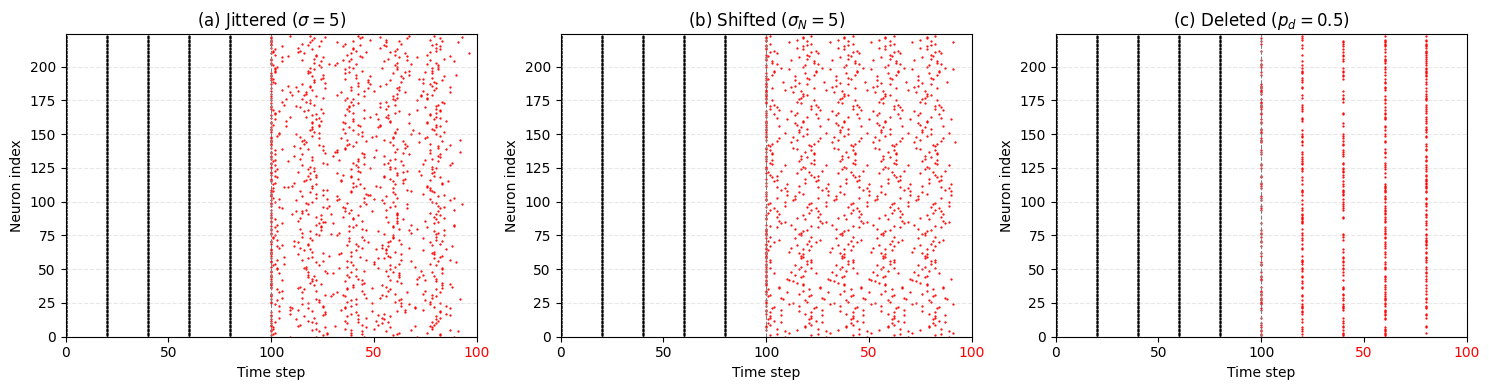

In [23]:
JITTER_SIGMA = 5.0
SHIFT_SIGMA = 5.0
DELETION_P = 0.5

np.random.seed(RNG_SEED)
jittered = jitter_spike_train(original_spikes, sigma=JITTER_SIGMA)

np.random.seed(RNG_SEED)
shifted = shift_spike_train(original_spikes, sigma=SHIFT_SIGMA)

np.random.seed(RNG_SEED)
deleted = delete_spike_train(original_spikes, p_d=DELETION_P)


def draw_side_by_side(
    ax: plt.Axes,
    original: np.ndarray,
    perturbed: np.ndarray,
    title: str,
) -> None:
    """Draw original (black, left) and perturbed (red, right) rasters on one axes."""
    _, T = original.shape
    orig_rows, orig_cols = np.where(original == 1)
    pert_rows, pert_cols = np.where(perturbed == 1)

    ax.scatter(orig_cols, orig_rows, s=1.5, c="black", marker=".")
    ax.scatter(pert_cols + T, pert_rows, s=1.5, c="red", marker=".")

    ax.axvline(T, color="gray", linestyle="--", linewidth=0.8)

    tick_positions = [0, T // 2, T, T + T // 2, 2 * T]
    tick_labels = ["0", str(T // 2), str(T), str(T // 2), str(T)]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    for label, pos in zip(ax.get_xticklabels(), tick_positions):
        if pos > T:
            label.set_color("red")

    ax.set_xlim(0, 2 * T)
    ax.set_ylim(0, original.shape[0])
    ax.set_xlabel("Time step")
    ax.set_ylabel("Neuron index")
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

draw_side_by_side(
    axes[0],
    original_spikes,
    jittered,
    rf"(a) Jittered ($\sigma={JITTER_SIGMA:g}$)",
)
draw_side_by_side(
    axes[1],
    original_spikes,
    shifted,
    rf"(b) Shifted ($\sigma_N={SHIFT_SIGMA:g}$)",
)
draw_side_by_side(
    axes[2],
    original_spikes,
    deleted,
    rf"(c) Deleted ($p_d={DELETION_P:g}$)",
)

plt.tight_layout()
plt.savefig("perturbation_methods_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

## Time reversal (inverse) perturbation

The inverse perturbation (from `inverse_train.ipynb`) flips the entire
sample within its **sample-wide active window** — the segment between
the earliest and latest spike across all neurons. Every neuron is
flipped with the same `t -> t_start + t_end - t` transform, so spike
counts, per-neuron ISI, and cross-neuron coincidences are preserved;
only the causal direction of time is reversed. Shown here in its own
panel so the symmetry around the sample midpoint is clearly visible.

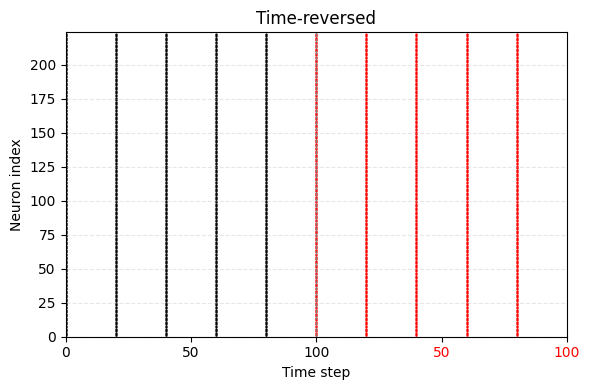

In [24]:
reversed_spikes = reverse_spike_train(original_spikes)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
draw_side_by_side(
    ax,
    original_spikes,
    reversed_spikes,
    "Time-reversed",
)

plt.tight_layout()
plt.savefig("perturbation_inverse_visualization.png", dpi=150, bbox_inches="tight")
plt.show()